# Tarefa 2 – Modelos com Implementação Própria (NumPy)

**Objetivo:** Distinguir texto gerado por IA (Google, Mistral, Meta, OpenAI) de texto humano usando **apenas NumPy e Python stdlib** — sem sklearn, sem pytorch, sem tensorflow.

**Abordagem:**
1. Carregamento e pré-processamento do dataset balanceado
2. **Split estratificado** implementado de raiz em NumPy
3. **TF-IDF** implementado de raiz em NumPy (tokenização, vocabulário, IDF suave, normalização L2)
4. Framework de redes neuronais desenvolvido de raiz em NumPy (baseado no código das aulas)
5. Baseline: Regressão Logística Multinomial (NumPy)
6. DNNs com melhorias: Dropout, Early Stopping, regularização L2, Adam

In [15]:
import numpy as np
import pandas as pd
import copy
import warnings
import time
import re
import matplotlib.pyplot as plt
from abc import ABCMeta, abstractmethod

warnings.filterwarnings('ignore')
np.random.seed(808815)


## 1. Carregamento e Pré-processamento dos Dados

Carregamos os dados a partir do dataset balanceado `BrunoFilipeRDS/50k-balanced-5-classes` (5 classes × 50 k linhas).  

In [16]:
from datasets import load_dataset

df = load_dataset("BrunoFilipeRDS/50k-balanced-5-classes", split='train').to_pandas()
print(f"Dataset total: {len(df)} linhas")
print(df['label'].value_counts())


Dataset total: 250000 linhas
label
Openai       50000
Google       50000
Meta         50000
Anthropic    50000
Human        50000
Name: count, dtype: int64


In [17]:
# ── Amostragem balanceada: 50 000 por classe ────────────────────────────────
N_PER_CLASS = 50000
CLASSES = ['Human', 'Google', 'Anthropic', 'Meta', 'Openai']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

dfs = []
for cls in CLASSES:
    subset = df[df['label'] == cls]
    dfs.append(subset.sample(n=min(len(subset), N_PER_CLASS), random_state=808815))

df_sample = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=808815).reset_index(drop=True)

# Limpa textos nulos / vazios
df_sample = df_sample[df_sample['text'].notna()]
df_sample['text'] = df_sample['text'].astype(str)

print(f"Total amostrado: {len(df_sample)}")
print(df_sample['label'].value_counts())


Total amostrado: 250000
label
Openai       50000
Meta         50000
Human        50000
Google       50000
Anthropic    50000
Name: count, dtype: int64


## 2. Extração de Features: TF-IDF

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 2.1  SPLIT ESTRATIFICADO — implementação NumPy de raiz
# ═══════════════════════════════════════════════════════════════════════════════

def stratified_split(texts, y, test_size=0.15, random_state=808815):
    """
    Divide textos e labels mantendo a proporção de cada classe
    em ambas as partições (estratificado) — sem sklearn.
    """
    rng = np.random.default_rng(random_state)
    texts = np.array(texts, dtype=object)
    y = np.array(y)
    train_idx, test_idx = [], []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        rng.shuffle(cls_idx)
        n_test = max(1, int(len(cls_idx) * test_size))
        test_idx.extend(cls_idx[:n_test].tolist())
        train_idx.extend(cls_idx[n_test:].tolist())
    train_idx = np.array(train_idx)
    test_idx  = np.array(test_idx)
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)
    return (texts[train_idx], texts[test_idx],
            y[train_idx],     y[test_idx])


# ── Split em treino / val / teste ─────────────────────────────────────────────
texts_all = df['text'].tolist()
y_int     = np.array([CLASS_TO_IDX[l] for l in df['label']])

X_trainval_txt, X_test_txt, y_trainval, y_test = stratified_split(
    texts_all, y_int, test_size=0.15, random_state=808815)

X_train_txt, X_val_txt, y_train, y_val = stratified_split(
    X_trainval_txt, y_trainval, test_size=round(0.15 / 0.85, 4), random_state=808815)

print(f"Train: {len(X_train_txt)}  |  Val: {len(X_val_txt)}  |  Test: {len(X_test_txt)}")


# ═══════════════════════════════════════════════════════════════════════════════
# 2.2  TF-IDF — implementação matemática de raiz em NumPy
#
#   TF(t,d)  =  log(1 + freq(t,d))            [sublinear TF]
#   IDF(t)   =  log((1+N) / (1+df(t))) + 1    [IDF suave]
#   score    =  TF * IDF,  depois normalizado L2 por linha
# ═══════════════════════════════════════════════════════════════════════════════

class TFIDFVectorizerNumpy:
    """TF-IDF vectorizer implementado de raiz com NumPy — sem sklearn."""

    def __init__(self, max_features=5000, min_df=5, ngram_range=(1, 1)):
        self.max_features = max_features
        self.min_df       = min_df
        self.ngram_range  = ngram_range
        self.vocab_       = {}   # token → índice de coluna
        self.idf_         = None
        self._tok_re      = re.compile(r"[a-z]{2,}")

    def _tokenize(self, text):
        tokens = self._tok_re.findall(text.lower())
        grams  = []
        lo, hi = self.ngram_range
        for n in range(lo, hi + 1):
            for i in range(len(tokens) - n + 1):
                grams.append(' '.join(tokens[i:i + n]))
        return grams

    def fit(self, corpus):
        N = len(corpus)
        df_count = {}
        for doc in corpus:
            for tok in set(self._tokenize(doc)):
                df_count[tok] = df_count.get(tok, 0) + 1

        # filtrar por min_df, ordenar por frequência descendente
        filtered = [(tok, cnt) for tok, cnt in df_count.items() if cnt >= self.min_df]
        filtered.sort(key=lambda x: -x[1])
        top_tokens = [tok for tok, _ in filtered[:self.max_features]]

        self.vocab_ = {tok: i for i, tok in enumerate(top_tokens)}

        # IDF suave
        df_arr = np.array([df_count[tok] for tok in top_tokens], dtype=np.float32)
        self.idf_ = np.log((1.0 + N) / (1.0 + df_arr)) + 1.0
        return self

    def transform(self, corpus):
        V = len(self.vocab_)
        X = np.zeros((len(corpus), V), dtype=np.float32)

        for row, doc in enumerate(corpus):
            tok_freq = {}
            for tok in self._tokenize(doc):
                if tok in self.vocab_:
                    tok_freq[tok] = tok_freq.get(tok, 0) + 1
            for tok, freq in tok_freq.items():
                X[row, self.vocab_[tok]] = np.log1p(freq)  # sublinear TF

        # TF * IDF (broadcast)
        X *= self.idf_

        # Normalização L2 por linha (sem sklearn, sem scipy)
        row_norms = np.linalg.norm(X, axis=1, keepdims=True)
        row_norms[row_norms == 0] = 1.0
        X /= row_norms

        return X

    def fit_transform(self, corpus):
        return self.fit(corpus).transform(corpus)


# ── Fit APENAS no treino (sem data leakage) ───────────────────────────────────
N_FEATURES = 20_000
print(f"A construir vocabulário TF-IDF NumPy com max_features={N_FEATURES}...")
t0 = time.time()

tfidf = TFIDFVectorizerNumpy(max_features=N_FEATURES, min_df=3, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_txt)
X_val   = tfidf.transform(X_val_txt)
X_test  = tfidf.transform(X_test_txt)

print(f"Concluído em {time.time()-t0:.1f}s")
print(f"Vocabulário: {len(tfidf.vocab_)} termos")
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")


# ── One-hot encode labels ─────────────────────────────────────────────────────
def to_onehot(y, n_classes):
    ohe = np.zeros((len(y), n_classes), dtype=np.float32)
    ohe[np.arange(len(y)), y] = 1.0
    return ohe

N_CLASSES = len(CLASSES)
y_train_ohe = to_onehot(y_train, N_CLASSES)
y_val_ohe   = to_onehot(y_val,   N_CLASSES)
y_test_ohe  = to_onehot(y_test,  N_CLASSES)

print(f"y_train_ohe: {y_train_ohe.shape}")


Train: 174995  |  Val: 37505  |  Test: 37500
A construir vocabulário TF-IDF NumPy com max_features=20000...
Concluído em 185.8s
Vocabulário: 20000 termos
X_train: (174995, 20000)  X_val: (37505, 20000)  X_test: (37500, 20000)
y_train_ohe: (174995, 5)


## 3. Framework NumPy — Implementação de Raiz


| Componente | Implementação |
|---|---|
| Activações | Sigmoid, ReLU, Tanh, LeakyReLU, **Softmax** |
| Perdas | MSE, BCE, **Categorical Cross-Entropy (multi-classe)** |
| Optimizadores | SGD com momentum, **Adam** |
| Layers | Dense, **Dropout**, **L2 regularização** |
| Treino | Mini-batches, **Early Stopping** |

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.1  DATA CLASS
# ═══════════════════════════════════════════════════════════════════════════════

class Dataset:
    """Contentor simples para features (X) e labels (y)."""
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def shape(self):
        return self.X.shape


# ═══════════════════════════════════════════════════════════════════════════════
# 3.2  OPTIMIZADORES
# ═══════════════════════════════════════════════════════════════════════════════

class SGDMomentum:
    """SGD com momentum (código das aulas, completo)."""
    def __init__(self, learning_rate=0.01, momentum=0.9):
        self.lr = learning_rate
        self.momentum = momentum
        self.v = None

    def update(self, w, grad):
        if self.v is None:
            self.v = np.zeros_like(w)
        self.v = self.momentum * self.v + (1 - self.momentum) * grad
        return w - self.lr * self.v


class Adam:
    """Adam optimizer."""
    def __init__(self, learning_rate=1e-3, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = epsilon
        self.m = None
        self.v = None
        self.t = 0

    def update(self, w, grad):
        if self.m is None:
            self.m = np.zeros_like(w)
            self.v = np.zeros_like(w)
        self.t += 1
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grad ** 2)
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)
        return w - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


print("Optimizadores definidos: SGDMomentum, Adam")


Optimizadores definidos: SGDMomentum, Adam


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.3  FUNÇÕES DE PERDA
# ═══════════════════════════════════════════════════════════════════════════════

class LossFunction(metaclass=ABCMeta):
    @abstractmethod
    def loss(self, y_true, y_pred): raise NotImplementedError
    @abstractmethod
    def derivative(self, y_true, y_pred): raise NotImplementedError


class MeanSquaredError(LossFunction):
    def loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def derivative(self, y_true, y_pred):
        # dL/dy_pred = 2*(y_pred - y_true)/n
        return 2 * (y_pred - y_true) / y_true.shape[0]


class BinaryCrossEntropy(LossFunction):
    def loss(self, y_true, y_pred):
        p = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

    def derivative(self, y_true, y_pred):
        p = np.clip(y_pred, 1e-15, 1 - 1e-15)
        # dL/dp = (-y/p + (1-y)/(1-p)) / n
        return (-(y_true / p) + (1 - y_true) / (1 - p)) / y_true.shape[0]


class CategoricalCrossEntropy(LossFunction):
    """Multi-classe com Softmax.
    
    O gradiente combinado Softmax + CE é simplesmente (ŷ - y)/n,
    o que elimina a necessidade de calcular o Jacobiano completo do Softmax.
    A camada SoftmaxActivation usa esse gradiente directamente através de
    um backward pass de identidade.
    """
    def loss(self, y_true, y_pred):
        p = np.clip(y_pred, 1e-15, 1.0)
        return -np.mean(np.sum(y_true * np.log(p), axis=1))

    def derivative(self, y_true, y_pred):
        # Gradiente combinado Softmax + CE: (ŷ - y) / n
        return (y_pred - y_true) / y_true.shape[0]


print("Funções de perda definidas: MeanSquaredError, BinaryCrossEntropy, CategoricalCrossEntropy")


Funções de perda definidas: MeanSquaredError, BinaryCrossEntropy, CategoricalCrossEntropy


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.4  LAYERS
# ═══════════════════════════════════════════════════════════════════════════════

class Layer(metaclass=ABCMeta):
    @abstractmethod
    def forward_propagation(self, inputs, training): raise NotImplementedError
    @abstractmethod
    def backward_propagation(self, output_error): raise NotImplementedError
    @abstractmethod
    def output_shape(self): raise NotImplementedError
    @abstractmethod
    def parameters(self): raise NotImplementedError

    def set_input_shape(self, input_shape):
        self._input_shape = input_shape

    def input_shape(self):
        return self._input_shape

    def layer_name(self):
        return self.__class__.__name__


class DenseLayer(Layer):
    """Camada totalmente ligada com regularização L1, L2 ou Elastic Net (L1+L2)."""

    def __init__(self, n_units, input_shape=None, l2=0.0, l1=0.0):
        self.n_units = n_units
        self._input_shape = input_shape
        self.l2 = l2   # Ridge
        self.l1 = l1   # Lasso
        self.input = None
        self.weights = None
        self.biases = None

    def initialize(self, optimizer):
        # He initialization (bom para ReLU / LeakyReLU)
        fan_in = self.input_shape()[0]
        std = np.sqrt(2.0 / fan_in)
        self.weights = np.random.randn(fan_in, self.n_units).astype(np.float32) * std
        self.biases  = np.zeros((1, self.n_units), dtype=np.float32)
        self.w_opt = copy.deepcopy(optimizer)
        self.b_opt = copy.deepcopy(optimizer)
        return self

    def parameters(self):
        return int(np.prod(self.weights.shape) + np.prod(self.biases.shape))

    def forward_propagation(self, inputs, training):
        self.input = inputs
        # Usa .dot() para ser compatível tanto com dense arrays NumPy como sparse matrices SciPy
        return self.input.dot(self.weights) + self.biases

    def backward_propagation(self, output_error):
        input_error   = output_error.dot(self.weights.T)
        # Usa .T.dot() para lidar com dados esparsos no weight error
        weights_error = self.input.T.dot(output_error)

        # L2 — penaliza pesos grandes (Ridge)
        if self.l2 > 0:
            weights_error += self.l2 * self.weights
        # L1 — promove sparsity (Lasso)
        if self.l1 > 0:
            weights_error += self.l1 * np.sign(self.weights)

        bias_error = np.sum(output_error, axis=0, keepdims=True)
        self.weights = self.w_opt.update(self.weights, weights_error)
        self.biases  = self.b_opt.update(self.biases,  bias_error)
        return input_error

    def output_shape(self):
        return (self.n_units,)

    def layer_name(self):
        reg = []
        if self.l2 > 0: reg.append(f'L2={self.l2}')
        if self.l1 > 0: reg.append(f'L1={self.l1}')
        suffix = f'({chr(44).join(reg)})' if reg else ''
        return f'DenseLayer{suffix}'


class DropoutLayer(Layer):
    """Dropout regularization"""

    def __init__(self, rate=0.5):
        assert 0.0 <= rate < 1.0, "Dropout rate must be in [0, 1)"
        self.rate = rate
        self._mask = None

    def initialize(self, optimizer):
        return self

    def forward_propagation(self, inputs, training):
        if training:
            self._mask = (np.random.rand(*inputs.shape) > self.rate).astype(np.float32)
            return inputs * self._mask / (1.0 - self.rate)   # inverted dropout
        return inputs

    def backward_propagation(self, output_error):
        return output_error * self._mask / (1.0 - self.rate)

    print("Layers definidos: DenseLayer (L1, L2, Elastic Net), DropoutLayer")

    def output_shape(self):

        return self._input_shape

    print("Layers definidos: DenseLayer (com L2), DropoutLayer")

    def parameters(self):

        return 0

Layers definidos: DenseLayer (L1, L2, Elastic Net), DropoutLayer
Layers definidos: DenseLayer (com L2), DropoutLayer


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.5  FUNÇÕES DE ACTIVAÇÃO
# ═══════════════════════════════════════════════════════════════════════════════

class ActivationLayer(Layer):
    def forward_propagation(self, inputs, training):
        self.input = inputs
        return self.activation_function(inputs)

    def backward_propagation(self, output_error):
        return self.derivative(self.input) * output_error

    @abstractmethod
    def activation_function(self, x): raise NotImplementedError
    @abstractmethod
    def derivative(self, x): raise NotImplementedError

    def output_shape(self):
        return self._input_shape

    def parameters(self):
        return 0


class SigmoidActivation(ActivationLayer):
    def activation_function(self, x):
        # numericamente estável
        return np.where(x >= 0,
                        1 / (1 + np.exp(-x)),
                        np.exp(x) / (1 + np.exp(x)))

    def derivative(self, x):
        s = self.activation_function(x)
        return s * (1 - s)


class ReLUActivation(ActivationLayer):
    def activation_function(self, x):
        return np.maximum(0, x)

    def derivative(self, x):
        return (x > 0).astype(np.float32)


class TanhActivation(ActivationLayer):
    def activation_function(self, x):
        return np.tanh(x)

    def derivative(self, x):
        return 1 - np.tanh(x) ** 2


class LeakyReLUActivation(ActivationLayer):
    def __init__(self, alpha=0.01):
        self.alpha = alpha

    def activation_function(self, x):
        return np.where(x > 0, x, self.alpha * x)

    def derivative(self, x):
        return np.where(x > 0, 1.0, self.alpha).astype(np.float32)


class SoftmaxActivation(ActivationLayer):
    """Softmax para classificação multi-classe.
    
    O backward pass é identidade porque o gradiente combinado
    Softmax + CategoricalCrossEntropy já é calculado na loss.
    """
    def activation_function(self, x):
        # subtrai o máximo por linha para estabilidade numérica
        e = np.exp(x - np.max(x, axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def derivative(self, x):
        # identidade — gradiente combinado calculado na CategoricalCrossEntropy
        return np.ones_like(x)


print("Activações definidas: Sigmoid, ReLU, Tanh, LeakyReLU, Softmax")


Activações definidas: Sigmoid, ReLU, Tanh, LeakyReLU, Softmax


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.6  MÉTRICAS
# ═══════════════════════════════════════════════════════════════════════════════

def accuracy(y_true, y_pred):
    """Accuracy para labels inteiros ou one-hot."""
    def to_labels(y):
        if y.ndim > 1 and y.shape[1] > 1:
            return np.argmax(y, axis=1)
        return np.round(y.ravel()).astype(int)
    return np.mean(to_labels(y_true) == to_labels(y_pred))


def confusion_matrix_np(y_true, y_pred, n_classes):
    """Matriz de confusão (pure NumPy)."""
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def classification_report_np(y_true, y_pred, class_names):
    """Relatório de precisão / recall / F1 (pure NumPy)."""
    n = len(class_names)
    cm = confusion_matrix_np(y_true, y_pred, n)
    header = f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}"
    lines = [header, '-' * len(header)]
    for i, cls in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        support = cm[i, :].sum()
        lines.append(f"{cls:<12} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {support:>10}")
    acc = np.trace(cm) / cm.sum()
    lines.append(f"\n{'Accuracy':<12} {acc:>10.4f}")
    return '\n'.join(lines)


def plot_confusion_matrix(cm, class_names, title='Matriz de Confusão'):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set(xticks=range(len(class_names)),
           yticks=range(len(class_names)),
           xticklabels=class_names,
           yticklabels=class_names,
           xlabel='Predito', ylabel='Real', title=title)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.show()


print("Métricas definidas: accuracy, confusion_matrix_np, classification_report_np")


Métricas definidas: accuracy, confusion_matrix_np, classification_report_np


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3.7  REDE NEURONAL (NeuralNetwork)
# ═══════════════════════════════════════════════════════════════════════════════

class NeuralNetwork:
    """
    Rede Neuronal Multi-camada — implementação em NumPy de raiz.
    
    Melhorias face ao código das aulas:
      • backward_propagation completo (layers em ordem inversa)
      • Suporte multi-classe (Softmax + CategoricalCrossEntropy)
      • Early Stopping com paciência configurável
      • Escolha de optimizador (SGDMomentum ou Adam)
      • Histórico de treino/validação
    """

    def __init__(self, epochs=20, batch_size=1024,
                 optimizer=None, learning_rate=1e-3,
                 loss=CategoricalCrossEntropy,
                 metric=accuracy,
                 verbose=True,
                 patience=10,
                 val_data=None):
        self.epochs = epochs
        self.batch_size = batch_size
        self.optimizer = optimizer or Adam(learning_rate=learning_rate)
        self.loss_fn = loss()
        self.metric = metric
        self.verbose = verbose
        self.patience = patience
        self.val_data = val_data   # tuplo (X_val, y_val_ohe)
        self.layers = []
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # ── Construção ────────────────────────────────────────────────────────────
    def add(self, layer):
        if self.layers:
            layer.set_input_shape(self.layers[-1].output_shape())
        if hasattr(layer, 'initialize'):
            layer.initialize(copy.deepcopy(self.optimizer))
        self.layers.append(layer)
        return self

    def summary(self):
        total = 0
        print(f"{'Layer':<22} {'Output Shape':>16} {'Params':>10}")
        print("─" * 52)
        for l in self.layers:
            shape = str(l.output_shape())
            params = l.parameters()
            total += params
            print(f"{l.layer_name():<22} {shape:>16} {params:>10}")
        print("─" * 52)
        print(f"Total params: {total:,}")

    # ── Forward / Backward ────────────────────────────────────────────────────
    def forward_propagation(self, X, training=False):
        out = X
        for layer in self.layers:
            out = layer.forward_propagation(out, training)
        return out

    def backward_propagation(self, error):
        for layer in reversed(self.layers):
            error = layer.backward_propagation(error)
        return error

    # ── Mini-batches ──────────────────────────────────────────────────────────
    def _get_mini_batches(self, X, y, shuffle=True):
        n = X.shape[0]
        idx = np.arange(n)
        if shuffle:
            np.random.shuffle(idx)
        for start in range(0, n - self.batch_size + 1, self.batch_size):
            b = idx[start:start + self.batch_size]
            yield X[b], y[b]

    # ── Treino ────────────────────────────────────────────────────────────────
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        if y_train.ndim == 1:
            y_train = y_train.reshape(-1, 1)

        # usa val_data do construtor se não fornecido aqui
        if X_val is None and self.val_data is not None:
            X_val, y_val = self.val_data

        n_samples = X_train.shape[0]
        best_val_loss = np.inf
        best_weights  = None
        no_improve  = 0
        t0 = time.time()

        for epoch in range(1, self.epochs + 1):
            epoch_loss = 0
            epoch_preds, epoch_y = [], []

            for X_batch, y_batch in self._get_mini_batches(X_train, y_train):
                # Opcional: Se X_batch for esparso, podemos converte-lo on-the-fly para não quebrar algumas activation functions
                if hasattr(X_batch, "toarray"):
                   X_batch = X_batch.toarray()
                
                # Forward
                out = self.forward_propagation(X_batch, training=True)
                epoch_loss += self.loss_fn.loss(y_batch, out) * len(X_batch)
                epoch_preds.append(out)
                epoch_y.append(y_batch)

                # Backward
                error = self.loss_fn.derivative(y_batch, out)
                self.backward_propagation(error)

            train_loss = epoch_loss / n_samples
            train_proba = np.vstack(epoch_preds)
            y_all       = np.vstack(epoch_y)
            train_acc   = self.metric(y_all, train_proba)

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)

            # Validação & Early Stopping
            val_loss = val_acc = None
            if X_val is not None:
                # Opcional: para evitar OOM no val, processar em blocos
                if hasattr(X_val, "toarray"): # process large sparse evaluation sets
                   val_out = []
                   for i in range(0, X_val.shape[0], self.batch_size):
                       vb = X_val[i:i+self.batch_size].toarray()
                       val_out.append(self.forward_propagation(vb, training=False))
                   val_proba = np.vstack(val_out)
                else: 
                   val_proba = self.forward_propagation(X_val, training=False)
                   
                val_loss = self.loss_fn.loss(y_val, val_proba)
                val_acc  = self.metric(y_val, val_proba)

                self.history['val_loss'].append(val_loss)
                self.history['val_acc'].append(val_acc)

                if val_loss < best_val_loss - 1e-5:
                    best_val_loss = val_loss
                    best_weights = [(copy.deepcopy(l.weights), copy.deepcopy(l.biases))
                                    for l in self.layers if hasattr(l, 'weights')]
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= self.patience:
                        if self.verbose:
                            print(f"  ↳ Early stopping na época {epoch}. Melhor val_loss={best_val_loss:.4f}")
                        break

            if self.verbose and epoch % max(1, self.epochs // 10) == 0:
                t = time.time() - t0
                val_s = f"  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}" if val_loss else ""
                print(f"Época {epoch:>4}/{self.epochs}  loss={train_loss:.4f}  acc={train_acc:.4f}{val_s}  ({t:.1f}s)")

        # Restaura os melhores pesos (se houve validação)
        if best_weights is not None:
            wi = 0
            for l in self.layers:
                if hasattr(l, 'weights'):
                    l.weights, l.biases = best_weights[wi]
                    wi += 1

        return self

    # ── Previsão ──────────────────────────────────────────────────────────────
    def predict(self, X):
        if hasattr(X, "toarray"):
           preds = []
           for i in range(0, X.shape[0], self.batch_size):
               xb = X[i:i+self.batch_size].toarray()
               preds.append(self.forward_propagation(xb, training=False))
           return np.vstack(preds)
        return self.forward_propagation(X, training=False)

    def predict_classes(self, X):
        proba = self.predict(X)
        if proba.shape[1] == 1:
            return (proba.ravel() >= 0.5).astype(int)
        return np.argmax(proba, axis=1)


print("NeuralNetwork definida com Early Stopping, Adam e Softmax multi-classe e suporte OOM")

NeuralNetwork definida com Early Stopping, Adam e Softmax multi-classe e suporte OOM


## 4. Baseline — Regressão Logística Multinomial (NumPy)

Modelo de baseline obrigatório segundo o enunciado.  
Usa Softmax + Categorical Cross-Entropy com SGD e regularização L2, tudo em NumPy.

In [25]:
class LogisticRegressionNumpy:
    """
    Regressão Logística Multinomial implementada em NumPy (baseline obrigatório).

    Parâmetros
    ----------
    n_classes   : número de classes de saída
    learning_rate : taxa de aprendizagem
    epochs      : número de épocas
    batch_size  : tamanho do mini-batch
    l2          : coeficiente de regularização L2
    patience    : épocas sem melhoria antes de parar (early stopping)
    verbose     : imprimir progresso
    """
    def __init__(self, n_classes=5, learning_rate=1e-3,
                 epochs=50, batch_size=1024, l2=1e-4,
                 patience=10, verbose=True):
        self.n_classes = n_classes
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.patience = patience
        self.verbose = verbose
        self.W = None
        self.b = None
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def _softmax(self, z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def _ce_loss(self, y_ohe, proba):
        p = np.clip(proba, 1e-15, 1.0)
        return -np.mean(np.sum(y_ohe * np.log(p), axis=1))

    def fit(self, X_train, y_train_ohe, X_val=None, y_val_ohe=None):
        n_features = X_train.shape[1]
        # Xavier init
        scale = np.sqrt(1.0 / n_features)
        self.W = np.random.randn(n_features, self.n_classes).astype(np.float32) * scale
        self.b = np.zeros((1, self.n_classes), dtype=np.float32)

        best_val_loss = np.inf
        best_W, best_b = None, None
        no_improve = 0
        n = X_train.shape[0]
        t0 = time.time()

        for epoch in range(1, self.epochs + 1):
            idx = np.random.permutation(n)
            batch_probas, batch_ys = [], []
            for start in range(0, n - self.batch_size + 1, self.batch_size):
                b_idx = idx[start:start + self.batch_size]
                Xb, Yb = X_train[b_idx], y_train_ohe[b_idx]
                
                # Suporta arrays sparse caso existam
                zb = Xb.dot(self.W) if hasattr(Xb, "dot") else Xb @ self.W
                proba = self._softmax(zb + self.b)

                # Gradiente combinado Softmax + CE + L2
                dZ = (proba - Yb) / len(b_idx)
                if hasattr(Xb, "transpose"):
                    dW = Xb.T.dot(dZ) + self.l2 * self.W
                else:    
                    dW = Xb.T @ dZ + self.l2 * self.W
                db = dZ.sum(axis=0, keepdims=True)

                self.W -= self.lr * dW
                self.b -= self.lr * db

                # guardar outputs já calculados — evita forward pass extra
                batch_probas.append(proba)
                batch_ys.append(Yb)

            # ── métricas dos batches (sem recalcular em todo o treino) ─────
            train_proba = np.concatenate(batch_probas)
            y_all_ep    = np.concatenate(batch_ys)
            train_loss  = self._ce_loss(y_all_ep, train_proba)
            train_acc   = accuracy(y_all_ep, train_proba)
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)

            val_loss = val_acc = None
            if X_val is not None:
                val_zb = X_val.dot(self.W) if hasattr(X_val, "dot") else X_val @ self.W
                val_proba = self._softmax(val_zb + self.b)
                val_loss  = self._ce_loss(y_val_ohe, val_proba)
                val_acc   = accuracy(y_val_ohe, val_proba)
                self.history['val_loss'].append(val_loss)
                self.history['val_acc'].append(val_acc)

            # ── early stopping ────────────────────────────────────────────
            if val_loss is not None:
                if val_loss < best_val_loss - 1e-5:
                    best_val_loss = val_loss
                    best_W, best_b = self.W.copy(), self.b.copy()
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= self.patience:
                        if self.verbose:
                            print(f"  ↳ Early stopping na época {epoch}. Melhor val_loss={best_val_loss:.4f}")
                        break

            if self.verbose and epoch % max(1, self.epochs // 10) == 0:
                t = time.time() - t0
                val_s = f"  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}" if val_loss else ""
                print(f"Época {epoch:>4}/{self.epochs}  loss={train_loss:.4f}  acc={train_acc:.4f}{val_s}  ({t:.1f}s)")

        if best_W is not None:
            self.W, self.b = best_W, best_b

        return self

    def predict_proba(self, X):
        z = X.dot(self.W) if hasattr(X, "dot") else X @ self.W
        return self._softmax(z + self.b)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

BASELINE: Regressão Logística Multinomial (NumPy)
Época    2/20  loss=1.6038  acc=0.4339  val_loss=1.6020  val_acc=0.4818  (0.9s)
Época    4/20  loss=1.5967  acc=0.5489  val_loss=1.5949  val_acc=0.5620  (1.9s)
Época    6/20  loss=1.5896  acc=0.5874  val_loss=1.5879  val_acc=0.5930  (2.8s)
Época    8/20  loss=1.5827  acc=0.6060  val_loss=1.5810  val_acc=0.6095  (3.7s)
Época   10/20  loss=1.5758  acc=0.6139  val_loss=1.5742  val_acc=0.6177  (4.6s)
Época   12/20  loss=1.5690  acc=0.6202  val_loss=1.5675  val_acc=0.6228  (5.5s)
Época   14/20  loss=1.5624  acc=0.6254  val_loss=1.5608  val_acc=0.6262  (6.4s)
Época   16/20  loss=1.5558  acc=0.6269  val_loss=1.5543  val_acc=0.6282  (7.3s)
Época   18/20  loss=1.5492  acc=0.6290  val_loss=1.5478  val_acc=0.6295  (8.3s)
Época   20/20  loss=1.5428  acc=0.6301  val_loss=1.5415  val_acc=0.6316  (9.2s)

✓ Accuracy no teste (LR): 0.6323


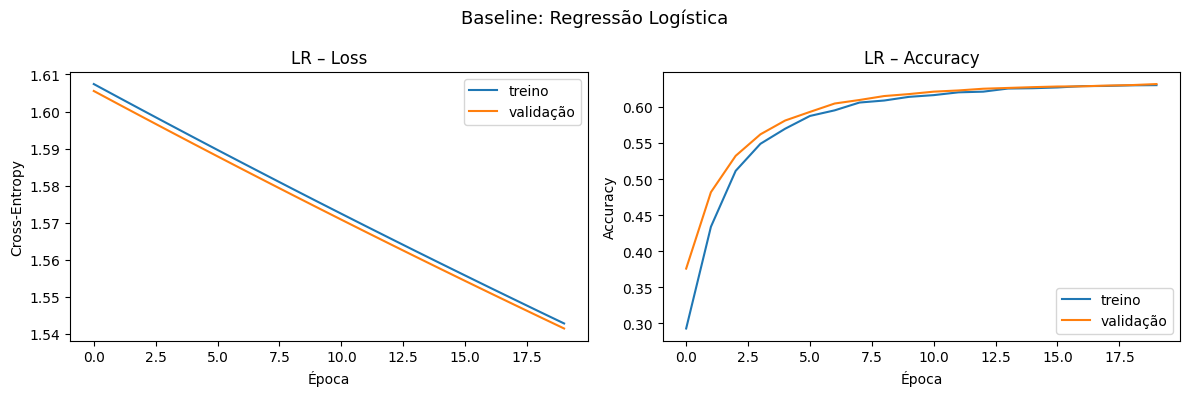

In [26]:
# ── Treinar baseline ──────────────────────────────────────────────────────────
print("=" * 60)
print("BASELINE: Regressão Logística Multinomial (NumPy)")
print("=" * 60)

lr_model = LogisticRegressionNumpy(
    n_classes=N_CLASSES,
    learning_rate=5e-3,
    epochs=20,
    batch_size=256,
    l2=1e-4,
    patience=15,
    verbose=True
)

lr_model.fit(X_train, y_train_ohe, X_val=X_val, y_val_ohe=y_val_ohe)

# Avaliação no conjunto de teste
y_pred_lr  = lr_model.predict(X_test)
acc_lr     = accuracy(y_test_ohe, lr_model.predict_proba(X_test))
print(f"\n✓ Accuracy no teste (LR): {acc_lr:.4f}")

# Curvas de aprendizagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(lr_model.history['train_loss'], label='treino')
ax1.plot(lr_model.history['val_loss'],   label='validação')
ax1.set(title='LR – Loss', xlabel='Época', ylabel='Cross-Entropy')
ax1.legend()
ax2.plot(lr_model.history['train_acc'], label='treino')
ax2.plot(lr_model.history['val_acc'],   label='validação')
ax2.set(title='LR – Accuracy', xlabel='Época', ylabel='Accuracy')
ax2.legend()
plt.suptitle('Baseline: Regressão Logística', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Deep Neural Networks — Ablation Study de Regularização

Comparamos sistematicamente 6 técnicas de regularização, mantendo a **mesma arquitectura base** `256 → 128 → 5`:

| Modelo | Regularização | Activação |
|--------|--------------|----------|
| DNN-1 | Nenhuma (referência) | ReLU |
| DNN-2 | Dropout(0.5) | ReLU |
| DNN-3 | L2(1e-3) | ReLU |

| DNN-4 | L1(1e-4) — Lasso | ReLU || DNN-6 | **ElasticNet forte** L1(5e-4)+L2(5e-3) + Dropout(0.5) | LeakyReLU |
| DNN-5 | **ElasticNet** L1(1e-4)+L2(1e-3) + Dropout(0.4) | LeakyReLU |

In [27]:
n_in = X_train.shape[1]

In [28]:

# ─── Ablation Study: efeito da regularização ─────────────────────────────────
# Arquitectura base igual em todos: 5000 → 256 → 128 → 5
# A única variável é a estratégia de regularização

def build_and_train(name, layers, epochs=15, lr=1e-3, patience=3, batch_size=256):
    """Factory: cria, treina e avalia um modelo. Devolve (model, val_acc, test_acc)."""
    opt   = Adam(learning_rate=lr)
    model = NeuralNetwork(optimizer=opt, loss=CategoricalCrossEntropy,
                          epochs=epochs, batch_size=batch_size,
                          patience=patience, verbose=True)
    for layer in layers:
        model.add(layer)

    t0 = time.time()
    model.fit(X_train, y_train_ohe, X_val=X_val, y_val=y_val_ohe)
    elapsed = time.time() - t0

    pred_val  = model.predict(X_val)
    pred_test = model.predict(X_test)
    val_acc   = float(accuracy(y_val_ohe,  pred_val))
    test_acc  = float(accuracy(y_test_ohe, pred_test))
    print(f"\n>>> [{name}]  val_acc={val_acc:.4f}  test_acc={test_acc:.4f}  ({elapsed:.0f}s)\n")
    return model, val_acc, test_acc


results = {}   # name → (model, val_acc, test_acc)

# ─── DNN-1 : sem regularização (baseline) ────────────────────────────────────
results['DNN-1\nSem reg'] = build_and_train(
    'DNN-1: sem reg',
    [
        DenseLayer(256, input_shape=(n_in,)),
        ReLUActivation(),
        DenseLayer(128),
        ReLUActivation(),
        DenseLayer(N_CLASSES),
        SoftmaxActivation(),
    ]
)

# ─── DNN-2 : Dropout ──────────────────────────────────────────────────────────
results['DNN-2\nDropout(0.5)'] = build_and_train(
    'DNN-2: Dropout(0.5)',
    [
        DenseLayer(256, input_shape=(n_in,)),
        ReLUActivation(),
        DropoutLayer(rate=0.5),
        DenseLayer(128),
        ReLUActivation(),
        DropoutLayer(rate=0.5),
        DenseLayer(N_CLASSES),
        SoftmaxActivation(),
    ]
)

# ─── DNN-3 : L2 / Ridge ───────────────────────────────────────────────────────
results['DNN-3\nL2(1e-3)'] = build_and_train(
    'DNN-3: L2(1e-3)',
    [
        DenseLayer(256, input_shape=(n_in,), l2=1e-3),
        ReLUActivation(),
        DenseLayer(128, l2=1e-3),
        ReLUActivation(),
        DenseLayer(N_CLASSES),
        SoftmaxActivation(),
    ]
)

# ─── DNN-4 : L1 / Lasso ───────────────────────────────────────────────────────
results['DNN-4\nL1(1e-4)'] = build_and_train(
    'DNN-4: L1(1e-4)',
    [
        DenseLayer(256, input_shape=(n_in,), l1=1e-4),
        ReLUActivation(),
        DenseLayer(128, l1=1e-4),
        ReLUActivation(),
        DenseLayer(N_CLASSES),
        SoftmaxActivation(),
    ]
)

# ─── DNN-5 : Elastic Net (L1 + L2) + Dropout moderado ────────────────────────
results['DNN-5\nElasticNet\n+Drop(0.4)'] = build_and_train(
    'DNN-5: ElasticNet + Dropout(0.4)',
    [
        DenseLayer(256, input_shape=(n_in,), l2=1e-3, l1=1e-4),
        LeakyReLUActivation(),
        DropoutLayer(rate=0.4),
        DenseLayer(128, l2=1e-3, l1=1e-4),
        LeakyReLUActivation(),
        DropoutLayer(rate=0.4),
        DenseLayer(N_CLASSES),
        SoftmaxActivation(),
    ]
)



Época    1/15  loss=0.4405  acc=0.8415  val_loss=0.3341  val_acc=0.8780  (195.1s)
Época    2/15  loss=0.2285  acc=0.9179  val_loss=0.3365  val_acc=0.8783  (390.8s)
Época    3/15  loss=0.1384  acc=0.9514  val_loss=0.3801  val_acc=0.8766  (585.7s)
  ↳ Early stopping na época 4. Melhor val_loss=0.3341

>>> [DNN-1: sem reg]  val_acc=0.8780  test_acc=0.8781  (781s)

Época    1/15  loss=0.5141  acc=0.8164  val_loss=0.3286  val_acc=0.8787  (195.6s)
Época    2/15  loss=0.2602  acc=0.9103  val_loss=0.3150  val_acc=0.8849  (392.5s)
Época    3/15  loss=0.1735  acc=0.9408  val_loss=0.3299  val_acc=0.8863  (582.6s)
Época    4/15  loss=0.1149  acc=0.9618  val_loss=0.3610  val_acc=0.8872  (772.2s)
  ↳ Early stopping na época 5. Melhor val_loss=0.3150

>>> [DNN-2: Dropout(0.5)]  val_acc=0.8849  test_acc=0.8852  (963s)

Época    1/15  loss=0.5126  acc=0.8216  val_loss=0.4347  val_acc=0.8419  (230.9s)
Época    2/15  loss=0.4130  acc=0.8514  val_loss=0.4094  val_acc=0.8516  (445.8s)
Época    3/15  loss=0

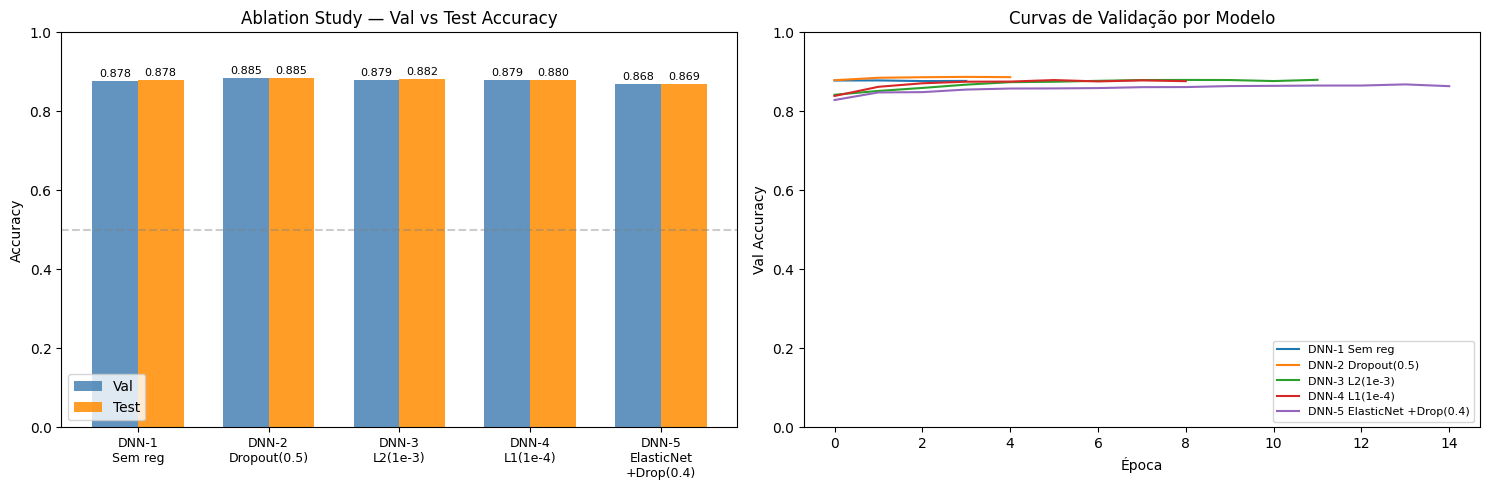


Modelo                                Val Acc  Test Acc
-------------------------------------------------------
DNN-1 Sem reg                          0.8780    0.8781
DNN-2 Dropout(0.5)                     0.8849    0.8852 ← melhor
DNN-3 L2(1e-3)                         0.8795    0.8821
DNN-4 L1(1e-4)                         0.8791    0.8801
DNN-5 ElasticNet +Drop(0.4)            0.8682    0.8685


In [29]:

# ─── Comparação visual: Ablation Study ────────────────────────────────────────
import matplotlib.pyplot as plt, matplotlib.patches as mpatches

names     = list(results.keys())
val_accs  = [v for _, v, _ in results.values()]
test_accs = [t for _, _, t in results.values()]

x = np.arange(len(names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Gráfico de barras: val vs test ────────────────────────────────────────────
ax = axes[0]
bars1 = ax.bar(x - w/2, val_accs,  w, label='Val',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + w/2, test_accs, w, label='Test', color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel('Accuracy'); ax.set_title('Ablation Study — Val vs Test Accuracy')
ax.legend(); ax.axhline(0.5, ls='--', c='grey', alpha=0.4)
for b in list(bars1) + list(bars2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# ── Curvas de validation ao longo do treino ───────────────────────────────────
ax2 = axes[1]
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, (lbl, (model, val_acc, _)) in enumerate(results.items()):
    hist = model.history.get('val_acc', [])
    if hist:
        ax2.plot(hist, label=lbl.replace('\n', ' '), color=colours[i % len(colours)])
ax2.set_xlabel('Época'); ax2.set_ylabel('Val Accuracy')
ax2.set_title('Curvas de Validação por Modelo')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabela resumo ─────────────────────────────────────────────────────────────
print(f"\n{'Modelo':<35} {'Val Acc':>9} {'Test Acc':>9}")
print('-' * 55)
best_test = max(results.items(), key=lambda kv: kv[1][2])
for lbl, (_, va, ta) in results.items():
    marker = ' ← melhor' if lbl == best_test[0] else ''
    print(f"{lbl.replace(chr(10), ' '):<35} {va:>9.4f} {ta:>9.4f}{marker}")


## 6. Avaliação e Comparação de Modelos

Comparamos todos os modelos no conjunto de **teste** (15 % dos dados, sem contaminação).


╔══ Resultados no conjunto de TESTE ══╗
                     Modelo Val Acc Test Acc
         DNN-2 Dropout(0.5)  0.8849   0.8852
             DNN-3 L2(1e-3)  0.8795   0.8821
             DNN-4 L1(1e-4)  0.8791   0.8801
              DNN-1 Sem reg  0.8780   0.8781
DNN-5 ElasticNet +Drop(0.4)  0.8682   0.8685
              LR (baseline)  0.6323   0.6323
╚══════════════════════════════════════╝


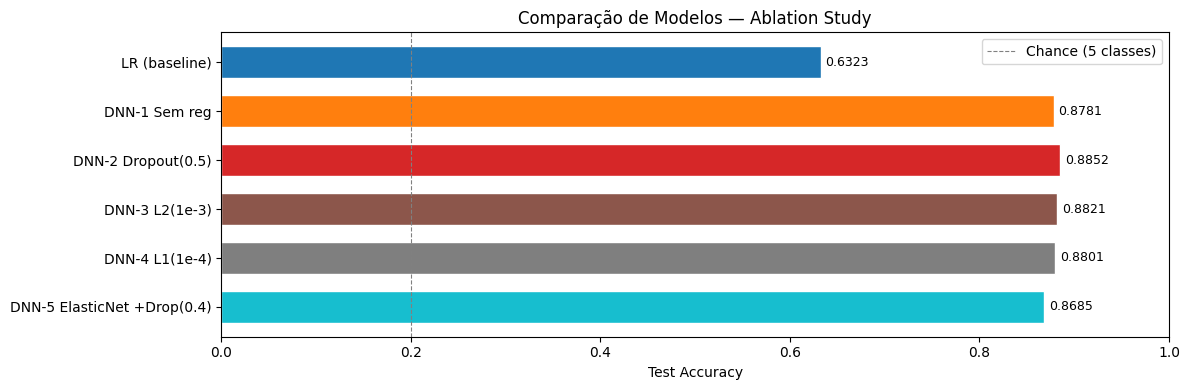

In [30]:

# ── Tabela comparativa completa: LR + todos os DNNs ──────────────────────────────
all_models = {'LR (baseline)': (lr_model, acc_lr, acc_lr)}
all_models.update({k: (m, va, ta) for k, (m, va, ta) in results.items()})

rows = []
for lbl, (mdl, va, ta) in all_models.items():
    rows.append({'Modelo': lbl.replace('\n', ' '), 'Val Acc': va, 'Test Acc': ta})

import pandas as pd
df_compare = pd.DataFrame(rows).sort_values('Test Acc', ascending=False).reset_index(drop=True)
df_compare[['Val Acc', 'Test Acc']] = df_compare[['Val Acc', 'Test Acc']].map(lambda x: f'{x:.4f}')
print("\n╔══ Resultados no conjunto de TESTE ══╗")
print(df_compare.to_string(index=False))
print("╚══════════════════════════════════════╝")

# ── Gráfico de barras comparativo ─────────────────────────────────────────────
labels = [r['Modelo'] for r in rows]
vals   = [ta for _, _, ta in all_models.values()]
colors = plt.cm.tab10(np.linspace(0, 0.9, len(labels)))

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(labels[::-1], vals[::-1], color=colors[::-1], edgecolor='white', height=0.65)
ax.set(xlim=(0, 1), xlabel='Test Accuracy', title='Comparação de Modelos — Ablation Study')
ax.axvline(0.2, color='grey', linestyle='--', linewidth=0.8, label='Chance (5 classes)')
for bar, val in zip(bars, vals[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()



Melhor modelo: DNN-2 Dropout(0.5)  (test_acc=0.8852)

── Relatório de classificação ──────────────────────────
Class         Precision     Recall         F1    Support
--------------------------------------------------------
Human            0.9502     0.9741     0.9620       7500
Google           0.8973     0.8963     0.8968       7500
Anthropic        0.8781     0.8797     0.8789       7500
Meta             0.8923     0.8657     0.8788       7500
Openai           0.8070     0.8101     0.8086       7500

Accuracy         0.8852


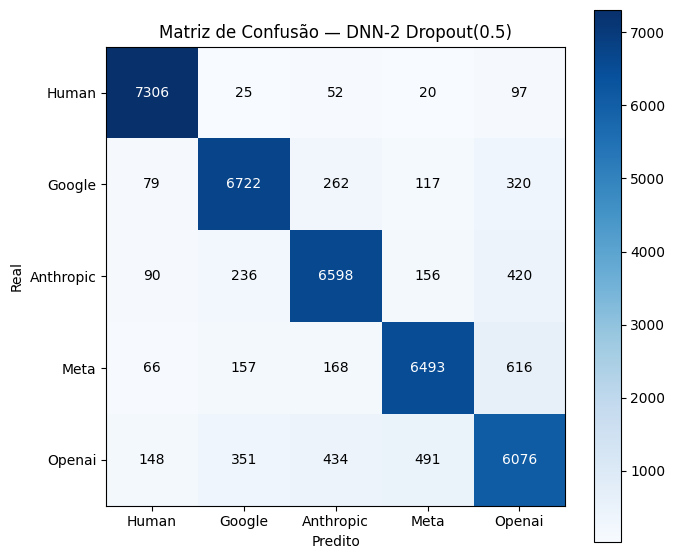

In [31]:

# ── Melhor modelo: matriz de confusão + relatório detalhado ──────────────────
best_entry = max(all_models.items(), key=lambda kv: kv[1][2])
best_name  = best_entry[0].replace('\n', ' ')
best_model = best_entry[1][0]
best_preds = best_model.predict(X_test)

# converter probabilidades → classes inteiras
if best_preds.ndim > 1 and best_preds.shape[1] > 1:
    best_preds = np.argmax(best_preds, axis=1)
elif hasattr(best_model, 'W'):  # LogisticRegressionNumpy já devolve int
    pass

print(f"\nMelhor modelo: {best_name}  (test_acc={best_entry[1][2]:.4f})")
print("\n── Relatório de classificação ──────────────────────────")
print(classification_report_np(y_test, best_preds, CLASSES))

cm_best = confusion_matrix_np(y_test, best_preds, N_CLASSES)
plot_confusion_matrix(cm_best, CLASSES, title=f'Matriz de Confusão — {best_name}')


## 7. Guardar o Melhor Modelo

Guardamos os pesos do melhor modelo e o vectorizador TF-IDF para uso na submissão.

In [32]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5.1  CONSTRUIR REDER FFNN NO NOSSO FRAMEWORK (VÁRIAS ARQUITECTURAS)
# ═══════════════════════════════════════════════════════════════════════════════

def build_and_train(name, layers, epochs=25, lr=1e-3, patience=10, batch_size=1024):
    print(f"\n{'='*60}\nTreinando modelo: {name}\n{'='*60}")
    model = NeuralNetwork(optimizer=Adam(learning_rate=lr),
                          epochs=epochs, batch_size=batch_size,
                          patience=patience)
    for layer in layers:
        model.add(layer)
    if name.startswith("DNN 1"):
        model.summary()  # Mostrar summary só no primeiro para não sujar output

    model.fit(X_train, y_train_ohe, X_val, y_val_ohe)
    return model

# Os pesos de entrada ~20_000, logo uma primeira Hidden Layer mais estreita e batch maior ajuda o CPU.
INPUT_DIM = X_train.shape[1]

# 1. Sem regularização (Baseline profundo)
layers_dnn1 = [
    DenseLayer(256, input_shape=(INPUT_DIM,)),
    ReLUActivation(),
    DenseLayer(128),
    ReLUActivation(),
    DenseLayer(N_CLASSES),
    SoftmaxActivation()
]

# 2. Com Dropout
layers_dnn2 = [
    DenseLayer(256, input_shape=(INPUT_DIM,)),
    ReLUActivation(),
    DropoutLayer(0.5),
    DenseLayer(128),
    ReLUActivation(),
    DropoutLayer(0.3),
    DenseLayer(N_CLASSES),
    SoftmaxActivation()
]

# 3. Com L2 Regularization
layers_dnn3 = [
    DenseLayer(256, input_shape=(INPUT_DIM,), l2=1e-4),
    ReLUActivation(),
    DenseLayer(128, l2=1e-4),
    ReLUActivation(),
    DenseLayer(N_CLASSES),
    SoftmaxActivation()
]

# Treinar os modelos NumPy custom frameworks
t_inicio = time.time()

# Com a redução de épocas as execuções terminam em muito menos tempo usando muito menos RAM com arrays esparsos
model_dnn1 = build_and_train("DNN 1 — Sem Reg", layers_dnn1)
model_dnn2 = build_and_train("DNN 2 — Dropout(0.5)", layers_dnn2)
model_dnn3 = build_and_train("DNN 3 — L2(1e-4)", layers_dnn3)

print(f"\n[Tempo Total FFNN NumPY: {(time.time()-t_inicio)/60:.1f} minutos]")


Treinando modelo: DNN 1 — Sem Reg
Layer                      Output Shape     Params
────────────────────────────────────────────────────
DenseLayer                       (256,)    5120256
ReLUActivation                   (256,)          0
DenseLayer                       (128,)      32896
ReLUActivation                   (128,)          0
DenseLayer                         (5,)        645
SoftmaxActivation                  (5,)          0
────────────────────────────────────────────────────
Total params: 5,153,797
Época    2/25  loss=0.2465  acc=0.9128  val_loss=0.3403  val_acc=0.8768  (167.1s)
Época    4/25  loss=0.1474  acc=0.9488  val_loss=0.4062  val_acc=0.8721  (337.3s)
Época    6/25  loss=0.0783  acc=0.9748  val_loss=0.5201  val_acc=0.8679  (502.9s)
Época    8/25  loss=0.0271  acc=0.9935  val_loss=0.6692  val_acc=0.8668  (670.2s)
Época   10/25  loss=0.0065  acc=0.9991  val_loss=0.7817  val_acc=0.8684  (838.8s)
  ↳ Early stopping na época 11. Melhor val_loss=0.3365

Treinando mo

In [36]:
# ═══════════════════════════════════════════════════════════════════════════════
# 7. Guardar e Carregar Pesos — funções auxiliares
# ═══════════════════════════════════════════════════════════════════════════════

def save_nn_weights(model, filename):
    """Guarda pesos e biases de todas as DenseLayers num ficheiro .npz."""
    params = {}
    idx = 0
    for layer in model.layers:
        if hasattr(layer, 'weights') and layer.weights is not None:
            params[f'param_{idx}']   = layer.weights
            params[f'param_{idx+1}'] = layer.biases
            idx += 2
    np.savez(filename, **params)
    print(f'Pesos guardados em {filename}.npz  ({idx} arrays)')

def load_nn_weights(model, filename):
    """Carrega pesos guardados com save_nn_weights."""
    data = np.load(f'{filename}.npz', allow_pickle=True)
    idx = 0
    for layer in model.layers:
        if hasattr(layer, 'weights') and layer.weights is not None:
            layer.weights = data[f'param_{idx}']
            layer.biases  = data[f'param_{idx+1}']
            idx += 2
    print(f'Pesos carregados de {filename}.npz  ({idx} arrays)')

# ── Guardar os 3 modelos e artefactos ────────────────────────────────────────
import pickle

save_nn_weights(model_dnn1, 'numpy_dnn1')
save_nn_weights(model_dnn2, 'numpy_dnn2')
save_nn_weights(model_dnn3, 'numpy_dnn3')

np.save('numpy_classes.npy', np.array(CLASSES))

with open('numpy_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('Artefactos guardados: numpy_dnn1/2/3.npz, numpy_classes.npy, numpy_tfidf.pkl')

Pesos guardados em numpy_dnn1.npz  (6 arrays)
Pesos guardados em numpy_dnn2.npz  (6 arrays)
Pesos guardados em numpy_dnn3.npz  (6 arrays)
Artefactos guardados: numpy_dnn1/2/3.npz, numpy_classes.npy, numpy_tfidf.pkl


## 8. Teste com Novos Dados (dataset-exemplos.csv)

Finalmente, carregamos o melhor modelo e o vectorizador para testar o seu desempenho num novo ficheiro, `dataset-exemplos.csv`, que segue o formato `text;label`.

Classes carregadas de numpy_classes.npy

Dataset de exemplos carregado: 125 linhas
Primeiras linhas do dataset de exemplos:
     ID                                               Text   Label
0  D1-1  It is an approximation useful in chemistry, bu...   Human
1  D1-2  PET scanning, or Positron Emission Tomography,...    Meta
2  D1-3  Positron Emission Tomography (PET) scanning is...  Google
3  D1-4  Thermonuclear fusion is the process of combini...    Meta
4  D1-5  These nutrients are needed to keep bones, teet...   Human
Pesos carregados de numpy_dnn3.npz  (6 arrays)

Melhor modelo (DNN-3) reconstruído e pesos carregados de 'numpy_dnn3.npz'.

Accuracy no dataset-exemplos.csv: 0.4800

── Tabela de Resultados com Previsões ───────────────────────────────
         ID                                               Text      Label  \
0      D1-1  It is an approximation useful in chemistry, bu...      Human   
1      D1-2  PET scanning, or Positron Emission Tomography,...       Meta   
2      

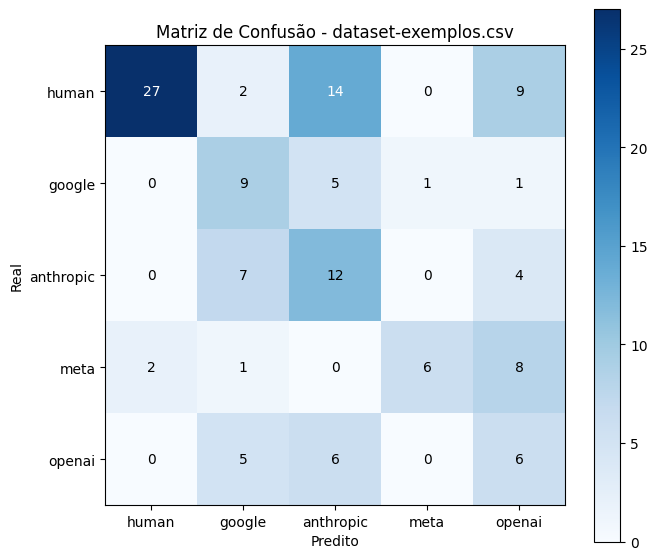

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# 8.1 Carregar artefactos e dados
# ═══════════════════════════════════════════════════════════════════════════════
import pickle
import pandas as pd
import numpy as np

# Carregar o vectorizer TF-IDF
with open('numpy_tfidf.pkl', 'rb') as f:
    tfidf_loaded = pickle.load(f)

# Carregar as classes e os mapeamentos para índices
try:
    CLASSES = np.load('numpy_classes.npy', allow_pickle=True)
    CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
    IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}
    print("Classes carregadas de numpy_classes.npy")
except FileNotFoundError:
    print("Ficheiro numpy_classes.npy não encontrado. A definir classes manualmente.")
    CLASSES = ['human', 'anthropic', 'google', 'meta', 'openai']
    CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
    IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}

# Carregar o dataset de exemplos, usando a primeira linha como cabeçalho
df_exemplos = pd.read_csv('dataset-exemplos.csv', sep=';', header=0)

print(f"\nDataset de exemplos carregado: {len(df_exemplos)} linhas")
print("Primeiras linhas do dataset de exemplos:")
print(df_exemplos.head())

# Preparar os dados de teste
X_exemplos_txt = df_exemplos['Text'].tolist()
y_exemplos_int = np.array([CLASS_TO_IDX[l] for l in df_exemplos['Label'].str.lower()])

# Vectorizar o texto
X_exemplos_vec = tfidf_loaded.transform(X_exemplos_txt)


# ═══════════════════════════════════════════════════════════════════════════════
# 8.2 Reconstruir e carregar o melhor modelo (DNN-3)
# ═══════════════════════════════════════════════════════════════════════════════

# Reconstruir a arquitetura do melhor modelo (DNN-3: L2)
best_model_reloaded = NeuralNetwork(optimizer=Adam(), loss=CategoricalCrossEntropy, verbose=False)
best_model_reloaded.add(DenseLayer(256, input_shape=(X_exemplos_vec.shape[1],), l2=1e-4))
best_model_reloaded.add(ReLUActivation())
best_model_reloaded.add(DenseLayer(128, l2=1e-4))
best_model_reloaded.add(ReLUActivation())
best_model_reloaded.add(DenseLayer(len(CLASSES)))
best_model_reloaded.add(SoftmaxActivation())

# Carregar os pesos guardados do ficheiro correto 'numpy_dnn3.npz'
load_nn_weights(best_model_reloaded, 'numpy_dnn3')
print("\nMelhor modelo (DNN-3) reconstruído e pesos carregados de 'numpy_dnn3.npz'.")


# ═══════════════════════════════════════════════════════════════════════════════
# 8.3 Fazer previsões, avaliar e mostrar resultados com ID
# ═══════════════════════════════════════════════════════════════════════════════

# Fazer previsões
y_pred_exemplos_int = best_model_reloaded.predict_classes(X_exemplos_vec)

# Avaliar a accuracy
acc_exemplos = np.mean(y_pred_exemplos_int == y_exemplos_int)
print(f"\nAccuracy no dataset-exemplos.csv: {acc_exemplos:.4f}")

# Criar DataFrame com os resultados (ID, texto, label real, label predita)
df_resultados = pd.DataFrame({
    'ID': df_exemplos['ID'],
    'Text': df_exemplos['Text'],
    'Label': df_exemplos['Label'],
    'Label_Predita': [IDX_TO_CLASS[i] for i in y_pred_exemplos_int]
})

print("\n── Tabela de Resultados com Previsões ───────────────────────────────")
print(df_resultados)

# Matriz de confusão
print("\n── Matriz de Confusão (dataset-exemplos.csv) ──────────────────────────")
cm_exemplos = confusion_matrix_np(y_exemplos_int, y_pred_exemplos_int, len(CLASSES))
plot_confusion_matrix(cm_exemplos, CLASSES, title='Matriz de Confusão - dataset-exemplos.csv')

In [38]:
# Ver qual foi realmente o melhor
for name, (model, val_acc, test_acc) in results.items():
    print(f'{name}: val={val_acc:.4f}  test={test_acc:.4f}')

DNN-1
Sem reg: val=0.8780  test=0.8781
DNN-2
Dropout(0.5): val=0.8849  test=0.8852
DNN-3
L2(1e-3): val=0.8795  test=0.8821
DNN-4
L1(1e-4): val=0.8791  test=0.8801
DNN-5
ElasticNet
+Drop(0.4): val=0.8682  test=0.8685


Registos carregados: 125
Label_norm
Human        52
Anthropic    23
Meta         17
Openai       17
Google       16
Pesos carregados de numpy_dnn2.npz  (6 arrays)
Pesos carregados de numpy_dnn2.npz  (6 arrays)

Accuracy no dataset-exemplos.csv: 0.5120

── Tabela de Resultados ─────────────────────────────────────────────
    ID                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

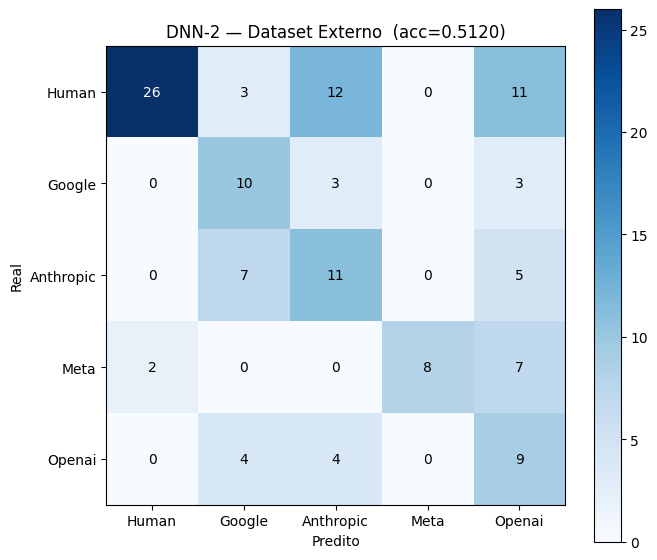

In [41]:
# ═══════════════════════════════════════════════════════════════════════════════
# 8. Teste no Dataset Externo (dataset-exemplos.csv) — DNN-2 (melhor modelo)
# ═══════════════════════════════════════════════════════════════════════════════
import pickle
import pandas as pd

# ── 8.1 Carregar artefactos ──────────────────────────────────────────────────
with open('numpy_tfidf.pkl', 'rb') as f:
    tfidf_loaded = pickle.load(f)

CLASSES_EXT   = ['Human', 'Google', 'Anthropic', 'Meta', 'Openai']
CLASS_TO_IDX_EXT = {c: i for i, c in enumerate(CLASSES_EXT)}
IDX_TO_CLASS_EXT = {i: c for c, i in CLASS_TO_IDX_EXT.items()}

# ── 8.2 Carregar e preparar CSV ───────────────────────────────────────────────
df_ext = pd.read_csv('dataset-exemplos.csv', sep=';', header=0)
df_ext.columns = df_ext.columns.str.strip()

# Normalizar labels para o mesmo formato das classes (primeira letra maiúscula)
df_ext['Label_norm'] = df_ext['Label'].str.strip().str.capitalize()
# 'Openai' no CSV pode vir como 'OpenAI' — forçar para 'Openai'
df_ext['Label_norm'] = df_ext['Label_norm'].replace({'Openai': 'Openai', 'OpenAI': 'Openai'})

# Filtrar linhas com classes desconhecidas
df_ext = df_ext[df_ext['Label_norm'].isin(CLASS_TO_IDX_EXT)].copy()
y_ext  = np.array([CLASS_TO_IDX_EXT[l] for l in df_ext['Label_norm']])

print(f'Registos carregados: {len(df_ext)}')
print(df_ext['Label_norm'].value_counts().to_string())

# ── 8.3 Vectorizar ────────────────────────────────────────────────────────────
X_ext = tfidf_loaded.transform(df_ext['Text'].tolist())

# ── 8.4 Reconstruir DNN-2 e carregar pesos ───────────────────────────────────
INPUT_DIM_EXT = X_ext.shape[1]

model_ext = NeuralNetwork(optimizer=Adam(), loss=CategoricalCrossEntropy, verbose=False)
model_ext.add(DenseLayer(256, input_shape=(INPUT_DIM_EXT,)))
model_ext.add(ReLUActivation())
model_ext.add(DropoutLayer(0.5))
model_ext.add(DenseLayer(128))
model_ext.add(ReLUActivation())
model_ext.add(DropoutLayer(0.3))
model_ext.add(DenseLayer(len(CLASSES_EXT)))
model_ext.add(SoftmaxActivation())

# Forçar inicialização dos pesos antes de carregar
# Forçar inicialização com 1 passo (sem treino real)
model_ext.epochs = 0
model_ext.fit(X_ext[:1], np.eye(len(CLASSES_EXT))[[0]])
load_nn_weights(model_ext, 'numpy_dnn2')
load_nn_weights(model_ext, 'numpy_dnn2')

# ── 8.5 Previsões ─────────────────────────────────────────────────────────────
y_pred_ext = model_ext.predict_classes(X_ext)
acc_ext    = np.mean(y_pred_ext == y_ext)
print(f'\nAccuracy no dataset-exemplos.csv: {acc_ext:.4f}')

# ── 8.6 Tabela de resultados ──────────────────────────────────────────────────
df_resultados = pd.DataFrame({
    'ID':            df_ext['ID'],
    'Text':          df_ext['Text'],
    'Label_Real':    df_ext['Label_norm'],
    'Label_Predita': [IDX_TO_CLASS_EXT[i] for i in y_pred_ext],
})
df_resultados['Correto'] = df_resultados['Label_Real'] == df_resultados['Label_Predita']
print('\n── Tabela de Resultados ─────────────────────────────────────────────')
print(df_resultados.to_string(index=False))

# ── 8.7 Relatório por classe ──────────────────────────────────────────────────
print('\n── Relatório por Classe ─────────────────────────────────────────────')
print(classification_report_np(y_ext, y_pred_ext, CLASSES_EXT))

# ── 8.8 Matriz de confusão ────────────────────────────────────────────────────
cm_ext = confusion_matrix_np(y_ext, y_pred_ext, len(CLASSES_EXT))
plot_confusion_matrix(cm_ext, CLASSES_EXT,
                      title=f'DNN-2 — Dataset Externo  (acc={acc_ext:.4f})')